In [1]:
import os
import gc
import pyarrow as pa
import pyarrow.parquet as pq
from nested_pandas.datasets import generate_data
from IPython import get_ipython

# Helper to format sizes
def format_size(size_in_bytes):
    for unit in ['B', 'KB', 'MB', 'GB']:
        if size_in_bytes < 1024.0:
            return f"{size_in_bytes:.2f} {unit}"
        size_in_bytes /= 1024.0

# 1. Define Configurations
size_configs = [
    (10, 200),      # Small base, small nested (Fast testing)
    (100, 2000),    # Medium (Your original baseline)
    (1000, 200),    # Many base rows, fewer nested rows ("Wide and shallow")
    (10, 20000),    # Few base rows, many nested rows ("Narrow and deep")
    (1000, 2000)    # Large dataset (Careful: This generates large files!)
]

compressions = [None, 'snappy', 'gzip', 'brotli', 'lz4', 'zstd']

# Dictionary to hold all final timing data
all_metrics = {}

ipython = get_ipython()

# 2. Main Execution Pipeline
for base_rows, nested_rows in size_configs:
    size_label = f"{base_rows} base x {nested_rows} nested"
    all_metrics[size_label] = {}
    
    print(f"\n{'='*60}\nTesting Size: {size_label}\n{'='*60}")
    
    # Generate the base datasets in RAM
    print("Generating data in memory...")
    nf = generate_data(base_rows, nested_rows, seed=1)[["nested"]]
    nf_lists = nf["nested"].to_lists()
    
    for comp in compressions:
        comp_name = "uncompressed" if comp is None else comp
        print(f"\n  --- Compression: {comp_name.upper()} ---")
        
        # Temporary file names
        nested_file = f"temp_nested_{comp_name}.parquet"
        list_file = f"temp_list_{comp_name}.parquet"
        
        # Save to disk
        nf.to_parquet(nested_file, compression=comp)
        nf_lists.to_parquet(list_file, compression=comp)
        
        nested_size = format_size(os.path.getsize(nested_file))
        list_size = format_size(os.path.getsize(list_file))
        print(f"  Files written to disk | Nested: {nested_size} | Flat: {list_size}")
        
        # Run benchmarks (Quiet mode -q, Output mode -o)
        print("  Benchmarking Flat Single...")
        flat_single = ipython.run_line_magic('timeit', f"-q -o pa.parquet.read_table('{list_file}', use_threads=False)")
        
        print("  Benchmarking Flat Multi...")
        flat_multi = ipython.run_line_magic('timeit', f"-q -o pa.parquet.read_table('{list_file}', use_threads=True)")
        
        print("  Benchmarking Nested Single...")
        nested_single = ipython.run_line_magic('timeit', f"-q -o pa.parquet.read_table('{nested_file}', use_threads=False)")
        
        print("  Benchmarking Nested Multi...")
        nested_multi = ipython.run_line_magic('timeit', f"-q -o pa.parquet.read_table('{nested_file}', use_threads=True)")
        
        # Extract the average time in seconds
        all_metrics[size_label][comp_name] = {
            'flat_single': flat_single.average,
            'flat_multi': flat_multi.average,
            'nested_single': nested_single.average,
            'nested_multi': nested_multi.average
        }
        
        # Discard the files from disk to save space
        os.remove(nested_file)
        os.remove(list_file)
        print("  Temporary files deleted.")

    # Free up RAM before the next massive data generation
    del nf
    del nf_lists
    gc.collect() 

# 3. Print the Final Comparison Tables
print("\n\n" + "#"*60)
print("FINAL BENCHMARK RESULTS (% FASTER/SLOWER THAN FLAT-SINGLE)")
print("#"*60)

for size_label, compressions_dict in all_metrics.items():
    print(f"\n=== Dataset Size: {size_label} ===")
    
    for comp_name, times in compressions_dict.items():
        baseline_time = times['flat_single']
        
        def calc_percent(current_time):
            return ((baseline_time - current_time) / baseline_time) * 100
            
        f_s_pct = calc_percent(times['flat_single'])
        n_s_pct = calc_percent(times['nested_single'])
        f_m_pct = calc_percent(times['flat_multi'])
        n_m_pct = calc_percent(times['nested_multi'])
        
        print(f"\nCompression: {comp_name.upper()}")
        print("| Threading | Flat                 | Nested               |")
        print("|-----------|----------------------|----------------------|")
        print(f"| Single    | {f_s_pct:>19.2f}% | {n_s_pct:>19.2f}% |")
        print(f"| Multi     | {f_m_pct:>19.2f}% | {n_m_pct:>19.2f}% |")


Testing Size: 10 base x 200 nested
Generating data in memory...

  --- Compression: UNCOMPRESSED ---
  Files written to disk | Nested: 38.88 KB | Flat: 40.93 KB
  Benchmarking Flat Single...
  Benchmarking Flat Multi...
  Benchmarking Nested Single...
  Benchmarking Nested Multi...
  Temporary files deleted.

  --- Compression: SNAPPY ---
  Files written to disk | Nested: 38.74 KB | Flat: 40.80 KB
  Benchmarking Flat Single...
  Benchmarking Flat Multi...
  Benchmarking Nested Single...
  Benchmarking Nested Multi...
  Temporary files deleted.

  --- Compression: GZIP ---
  Files written to disk | Nested: 37.16 KB | Flat: 39.21 KB
  Benchmarking Flat Single...
  Benchmarking Flat Multi...
  Benchmarking Nested Single...
  Benchmarking Nested Multi...
  Temporary files deleted.

  --- Compression: BROTLI ---
  Files written to disk | Nested: 37.10 KB | Flat: 39.16 KB
  Benchmarking Flat Single...
  Benchmarking Flat Multi...
  Benchmarking Nested Single...
  Benchmarking Nested Multi..

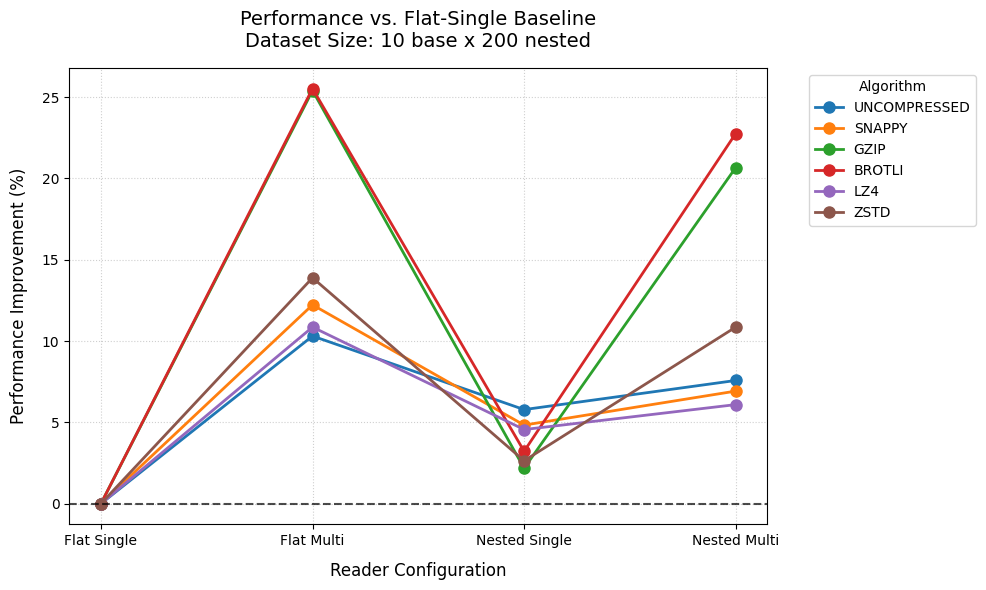

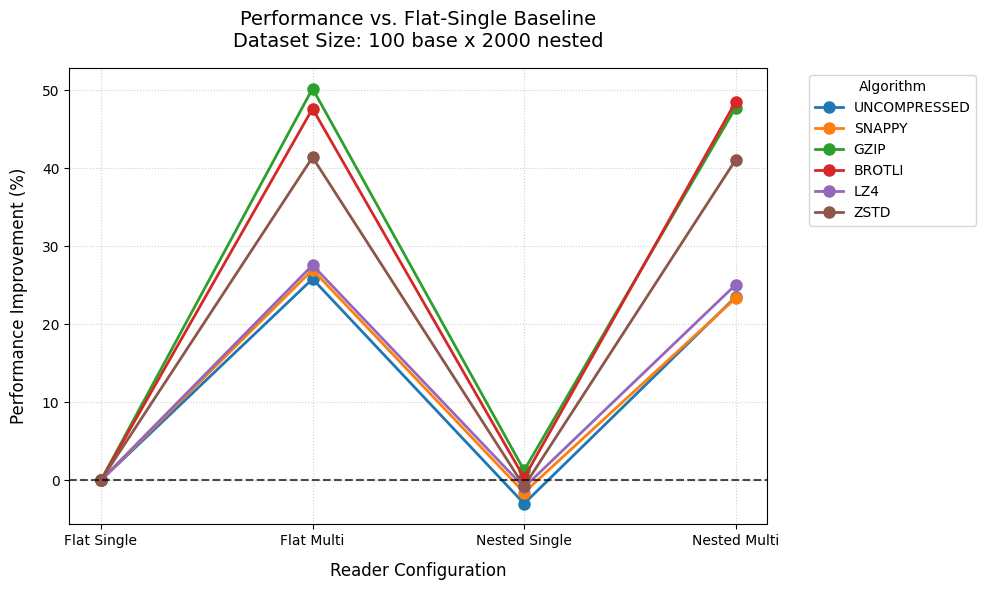

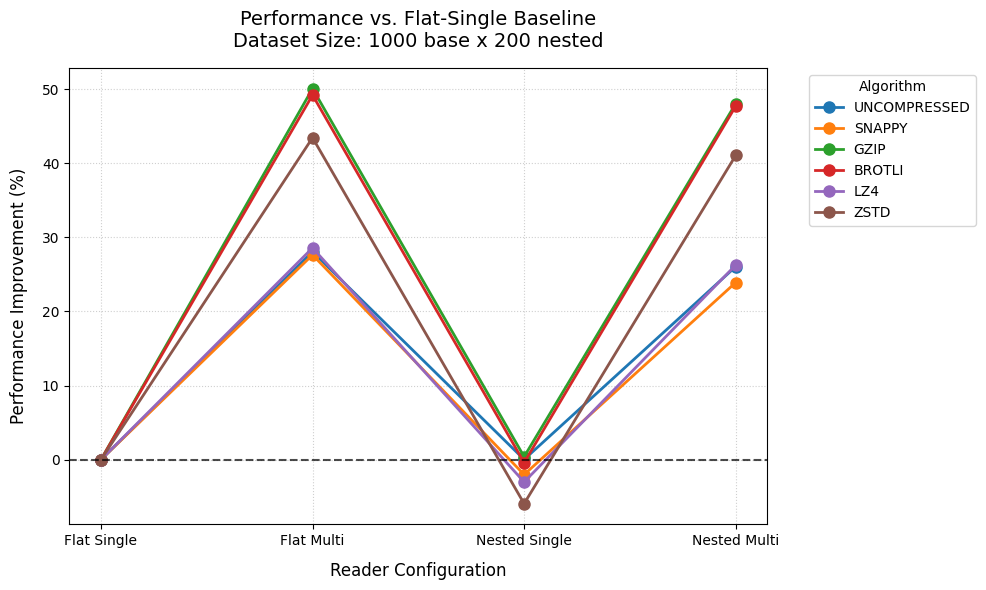

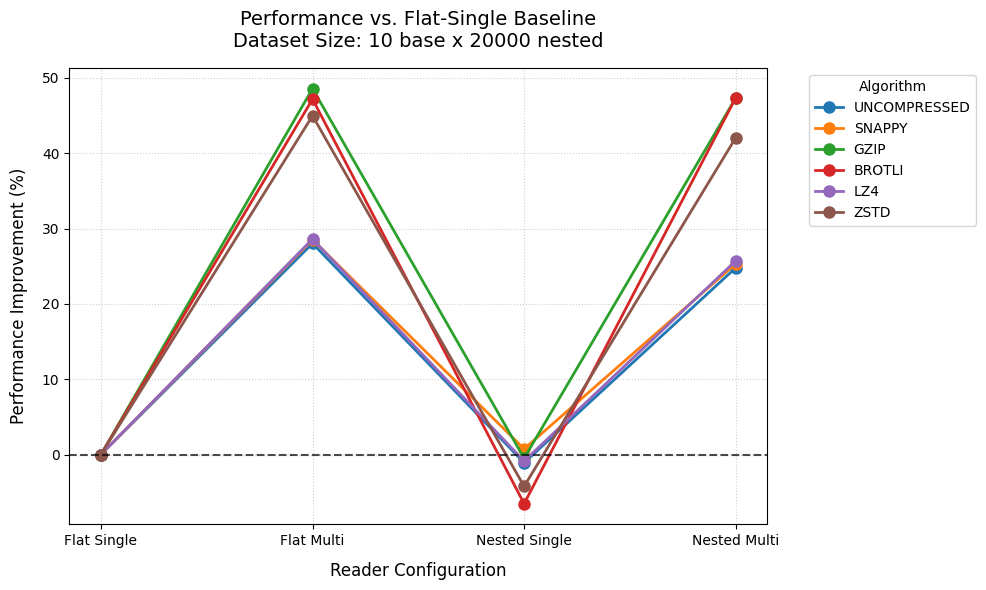

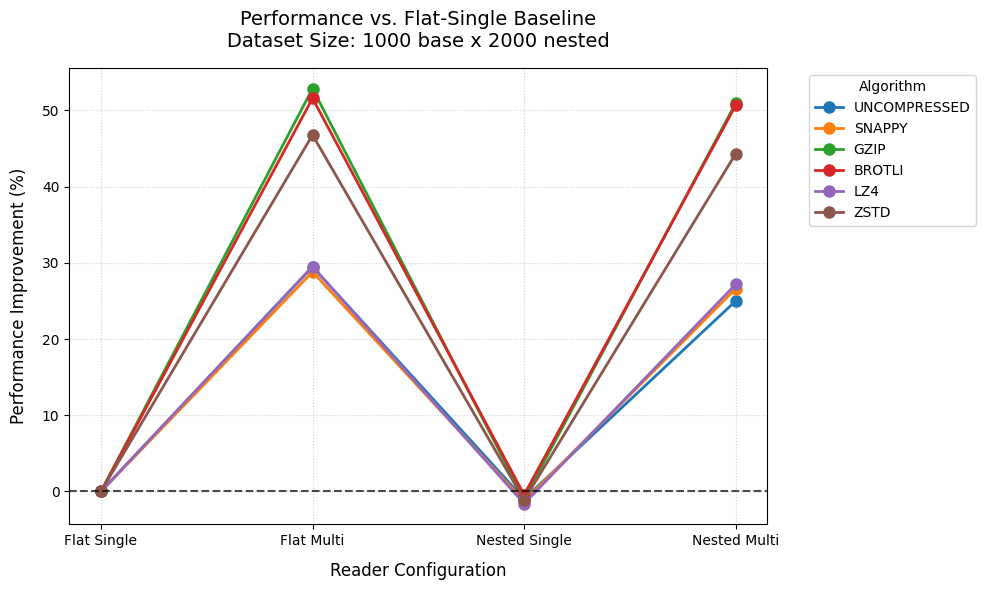

In [2]:
import matplotlib.pyplot as plt

# Loop through each dataset size (b x n configurations) to create a separate chart
for size_label, compressions_dict in all_metrics.items():
    
    # Set up the figure size
    plt.figure(figsize=(10, 6))
    
    # X-axis categories corresponding to the reader configs
    reader_configs = ['Flat Single', 'Flat Multi', 'Nested Single', 'Nested Multi']
    
    # Plot a line for each compression algorithm
    for comp_name, times in compressions_dict.items():
        baseline_time = times['flat_single']
        
        # Calculate % improvement (positive = faster, negative = slower)
        def calc_percent(current_time):
            return ((baseline_time - current_time) / baseline_time) * 100
            
        y_values = [
            calc_percent(times['flat_single']),   # Will always be 0%
            calc_percent(times['flat_multi']),
            calc_percent(times['nested_single']),
            calc_percent(times['nested_multi'])
        ]
        
        # Plot the line with markers to highlight the specific data points
        plt.plot(
            reader_configs, 
            y_values, 
            marker='o', 
            markersize=8, 
            linewidth=2, 
            label=comp_name.upper()
        )
        
    # Formatting the chart
    plt.title(f"Performance vs. Flat-Single Baseline\nDataset Size: {size_label}", fontsize=14, pad=15)
    plt.xlabel("Reader Configuration", fontsize=12, labelpad=10)
    plt.ylabel("Performance Improvement (%)", fontsize=12, labelpad=10)
    
    # Add a bold dashed line at 0% so it's easy to see what is slower than the baseline
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Styling
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(title="Algorithm", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout() # Ensures the legend isn't cut off
    
    # Render the plot
    plt.show()

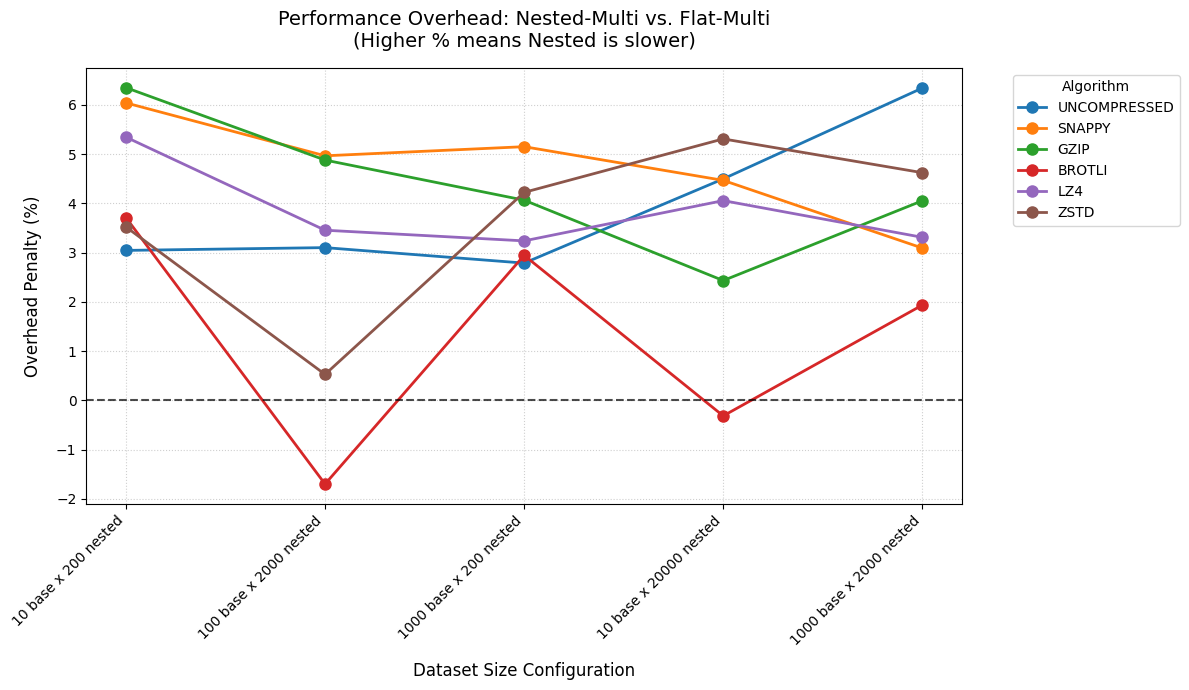

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Extract the list of sizes and compressions from our metrics dictionary
size_labels = list(all_metrics.keys())
compressions = list(all_metrics[size_labels[0]].keys())

# Plot one line for each compression algorithm
for comp_name in compressions:
    y_values = []
    
    for size in size_labels:
        times = all_metrics[size][comp_name]
        flat_m_time = times['flat_multi']
        nest_m_time = times['nested_multi']
        
        # Calculate Overhead Penalty (%)
        # Formula: ((Nested Time - Flat Time) / Flat Time) * 100
        # Positive value = Nested took MORE time (it has a penalty/overhead)
        # Negative value = Nested took LESS time (it is somehow faster)
        overhead_pct = ((nest_m_time - flat_m_time) / flat_m_time) * 100
        y_values.append(overhead_pct)
        
    plt.plot(
        size_labels, 
        y_values, 
        marker='o', 
        markersize=8, 
        linewidth=2, 
        label=comp_name.upper()
    )

# Formatting the chart
plt.title("Performance Overhead: Nested-Multi vs. Flat-Multi\n(Higher % means Nested is slower)", fontsize=14, pad=15)
plt.xlabel("Dataset Size Configuration", fontsize=12, labelpad=10)
plt.ylabel("Overhead Penalty (%)", fontsize=12, labelpad=10)

# Add a baseline at 0% (where Nested and Flat take the exact same amount of time)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# Rotate X-axis labels so they don't overlap if you have many sizes
plt.xticks(rotation=45, ha='right')

# Styling
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Algorithm", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Render the plot
plt.show()

In [7]:
import os
import gc
import time
import pyarrow as pa
import pyarrow.parquet as pq
from nested_pandas.datasets import generate_data

# ==========================================
# 1. Helper Functions
# ==========================================
def format_size(size_in_bytes):
    for unit in ['B', 'KB', 'MB', 'GB']:
        if size_in_bytes < 1024.0:
            return f"{size_in_bytes:.2f} {unit}"
        size_in_bytes /= 1024.0

def pre_warm_cache(filepath):
    """
    Reads the file's raw bytes directly, forcing the OS to load it into RAM.
    This bypasses PyArrow entirely and ensures the file is completely cached.
    """
    with open(filepath, 'rb') as f:
        # Read in 10 MB chunks and discard to avoid filling Python's memory.
        # The Operating System will keep the chunks in its page cache.
        while f.read(10 * 1024 * 1024):
            pass

def benchmark_warm_read(filepath, use_threads, num_runs=3):
    """Ensures the file is in RAM, then times the PyArrow read."""
    
    # 1. Force the file into the OS RAM cache
    pre_warm_cache(filepath)
    
    total_time = 0.0
    
    for _ in range(num_runs):
        # 2. Start the timer ONLY for the PyArrow CPU operation
        start_time = time.perf_counter()
        
        table = pa.parquet.read_table(filepath, use_threads=use_threads)
        
        end_time = time.perf_counter()
        total_time += (end_time - start_time)
        
        # 3. Safely free PyArrow's memory before the next loop
        del table
        gc.collect()
        
    return total_time / num_runs


# ==========================================
# 2. Define Configurations
# ==========================================
size_configs = [
    (10, 200),      # Small base, small nested (Fast testing)
    (100, 2000),    # Medium (Your original baseline)
    (1000, 200),    # Many base rows, fewer nested rows ("Wide and shallow")
    (10, 20000),    # Few base rows, many nested rows ("Narrow and deep")
    (1000, 2000)    # Large dataset (Careful: This generates large files!)
]

compressions = [None, 'snappy', 'gzip', 'brotli', 'lz4', 'zstd']

# Dictionary to hold all final timing data
all_metrics = {}


# ==========================================
# 3. Main Execution Pipeline
# ==========================================
for base_rows, nested_rows in size_configs:
    size_label = f"{base_rows} base x {nested_rows} nested"
    all_metrics[size_label] = {}
    
    print(f"\n{'='*60}\nTesting Size: {size_label}\n{'='*60}")
    
    # Generate the base datasets in RAM
    print("Generating data in memory...")
    nf = generate_data(base_rows, nested_rows, seed=1)[["nested"]]
    nf_lists = nf["nested"].to_lists()
    
    for comp in compressions:
        comp_name = "uncompressed" if comp is None else comp
        print(f"\n  --- Compression: {comp_name.upper()} ---")
        
        # Temporary file names
        nested_file = f"temp_nested_{comp_name}.parquet"
        list_file = f"temp_list_{comp_name}.parquet"
        
        # Save to disk
        nf.to_parquet(nested_file, compression=comp)
        nf_lists.to_parquet(list_file, compression=comp)
        
        nested_size = format_size(os.path.getsize(nested_file))
        list_size = format_size(os.path.getsize(list_file))
        print(f"  Files written to disk | Nested: {nested_size} | Flat: {list_size}")
        
        # Run benchmarks using our custom warm loop (No IPython magics needed)
        print("  Benchmarking Flat Single (Warm)...")
        flat_single_time = benchmark_warm_read(list_file, use_threads=False)
        
        print("  Benchmarking Flat Multi (Warm)...")
        flat_multi_time = benchmark_warm_read(list_file, use_threads=True)
        
        print("  Benchmarking Nested Single (Warm)...")
        nested_single_time = benchmark_warm_read(nested_file, use_threads=False)
        
        print("  Benchmarking Nested Multi (Warm)...")
        nested_multi_time = benchmark_warm_read(nested_file, use_threads=True)
        
        # Extract the average time in seconds
        all_metrics[size_label][comp_name] = {
            'flat_single': flat_single_time,
            'flat_multi': flat_multi_time,
            'nested_single': nested_single_time,
            'nested_multi': nested_multi_time
        }
        
        # Discard the files from disk to save space
        os.remove(nested_file)
        os.remove(list_file)
        print("  Temporary files deleted.")

    # Free up RAM before the next massive data generation
    del nf
    del nf_lists
    gc.collect() 


# ==========================================
# 4. Print the Final Comparison Tables
# ==========================================
print("\n\n" + "#"*60)
print("FINAL BENCHMARK RESULTS (% FASTER/SLOWER THAN FLAT-SINGLE)")
print("#"*60)

for size_label, compressions_dict in all_metrics.items():
    print(f"\n=== Dataset Size: {size_label} ===")
    
    for comp_name, times in compressions_dict.items():
        baseline_time = times['flat_single']
        
        def calc_percent(current_time):
            return ((baseline_time - current_time) / baseline_time) * 100
            
        f_s_pct = calc_percent(times['flat_single'])
        n_s_pct = calc_percent(times['nested_single'])
        f_m_pct = calc_percent(times['flat_multi'])
        n_m_pct = calc_percent(times['nested_multi'])
        
        print(f"\nCompression: {comp_name.upper()}")
        print("| Threading | Flat                 | Nested               |")
        print("|-----------|----------------------|----------------------|")
        print(f"| Single    | {f_s_pct:>19.2f}% | {n_s_pct:>19.2f}% |")
        print(f"| Multi     | {f_m_pct:>19.2f}% | {n_m_pct:>19.2f}% |")


Testing Size: 10 base x 200 nested
Generating data in memory...

  --- Compression: UNCOMPRESSED ---
  Files written to disk | Nested: 38.88 KB | Flat: 40.93 KB
  Benchmarking Flat Single (Warm)...
  Benchmarking Flat Multi (Warm)...
  Benchmarking Nested Single (Warm)...
  Benchmarking Nested Multi (Warm)...
  Temporary files deleted.

  --- Compression: SNAPPY ---
  Files written to disk | Nested: 38.74 KB | Flat: 40.80 KB
  Benchmarking Flat Single (Warm)...
  Benchmarking Flat Multi (Warm)...
  Benchmarking Nested Single (Warm)...
  Benchmarking Nested Multi (Warm)...
  Temporary files deleted.

  --- Compression: GZIP ---
  Files written to disk | Nested: 37.16 KB | Flat: 39.21 KB
  Benchmarking Flat Single (Warm)...
  Benchmarking Flat Multi (Warm)...
  Benchmarking Nested Single (Warm)...
  Benchmarking Nested Multi (Warm)...
  Temporary files deleted.

  --- Compression: BROTLI ---
  Files written to disk | Nested: 37.10 KB | Flat: 39.16 KB
  Benchmarking Flat Single (Warm)...

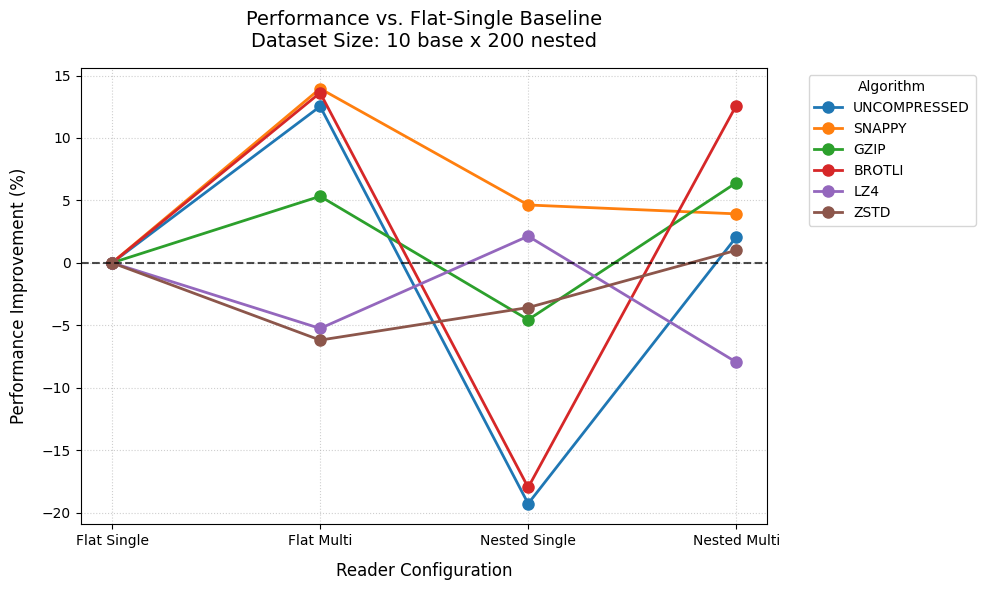

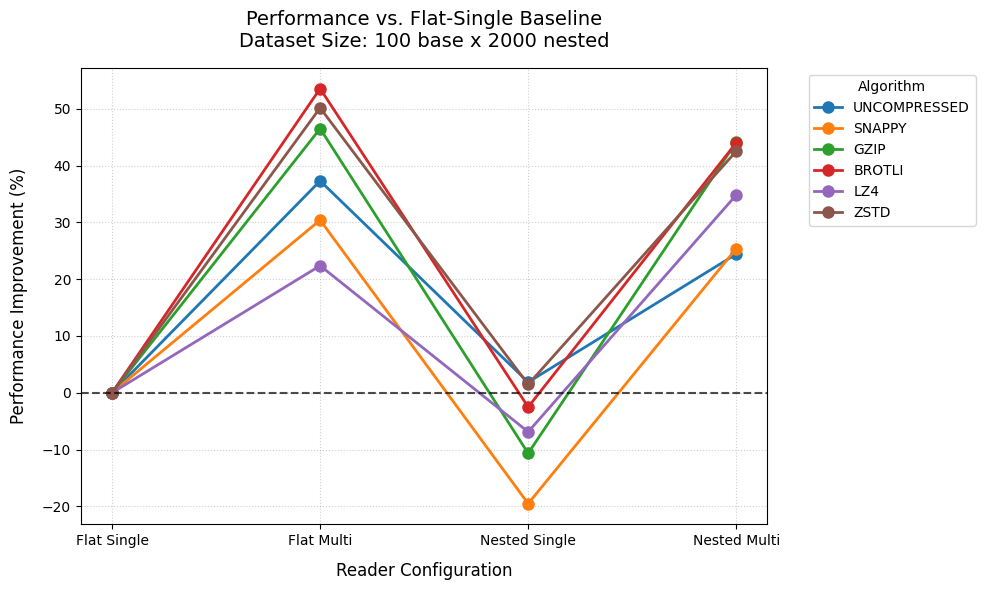

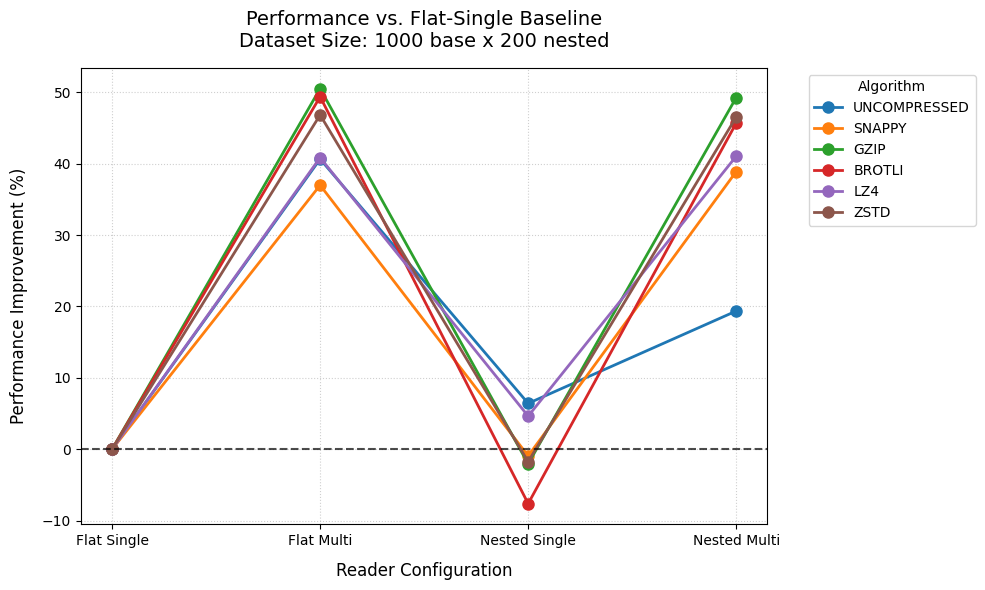

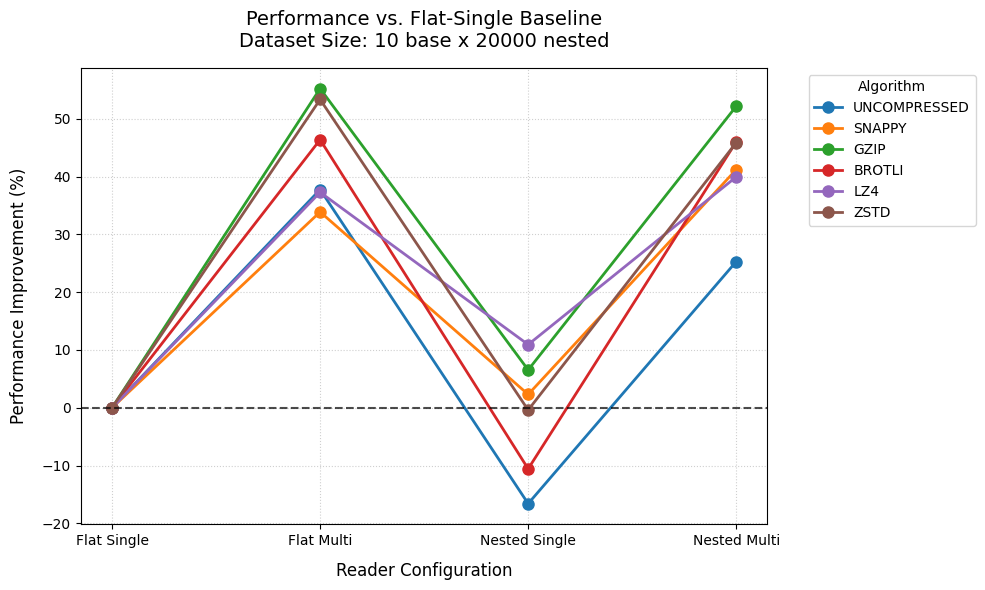

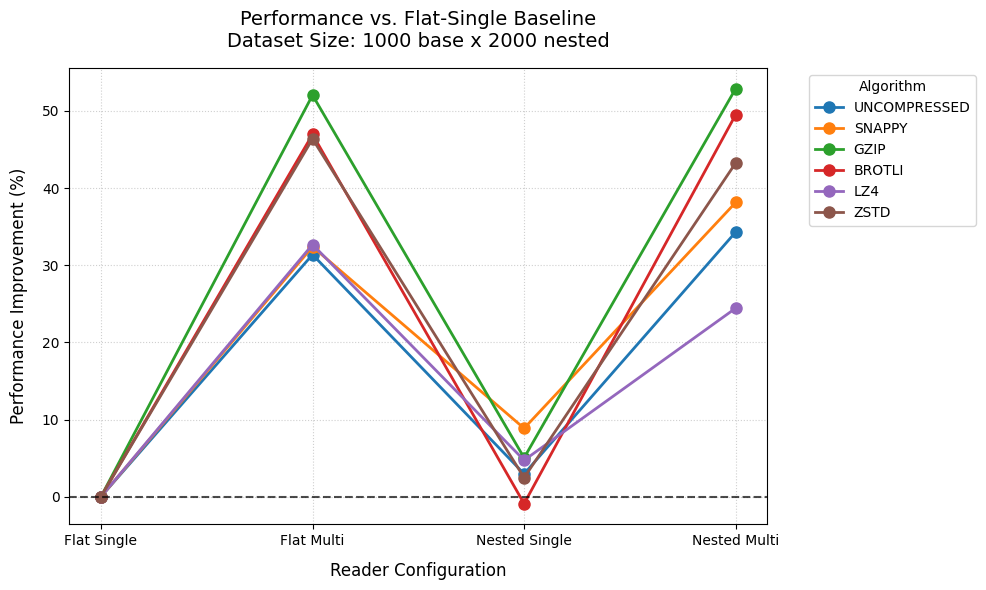

In [8]:
import matplotlib.pyplot as plt

# Loop through each dataset size (b x n configurations) to create a separate chart
for size_label, compressions_dict in all_metrics.items():
    
    # Set up the figure size
    plt.figure(figsize=(10, 6))
    
    # X-axis categories corresponding to the reader configs
    reader_configs = ['Flat Single', 'Flat Multi', 'Nested Single', 'Nested Multi']
    
    # Plot a line for each compression algorithm
    for comp_name, times in compressions_dict.items():
        baseline_time = times['flat_single']
        
        # Calculate % improvement (positive = faster, negative = slower)
        def calc_percent(current_time):
            return ((baseline_time - current_time) / baseline_time) * 100
            
        y_values = [
            calc_percent(times['flat_single']),   # Will always be 0%
            calc_percent(times['flat_multi']),
            calc_percent(times['nested_single']),
            calc_percent(times['nested_multi'])
        ]
        
        # Plot the line with markers to highlight the specific data points
        plt.plot(
            reader_configs, 
            y_values, 
            marker='o', 
            markersize=8, 
            linewidth=2, 
            label=comp_name.upper()
        )
        
    # Formatting the chart
    plt.title(f"Performance vs. Flat-Single Baseline\nDataset Size: {size_label}", fontsize=14, pad=15)
    plt.xlabel("Reader Configuration", fontsize=12, labelpad=10)
    plt.ylabel("Performance Improvement (%)", fontsize=12, labelpad=10)
    
    # Add a bold dashed line at 0% so it's easy to see what is slower than the baseline
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Styling
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(title="Algorithm", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout() # Ensures the legend isn't cut off
    
    # Render the plot
    plt.show()

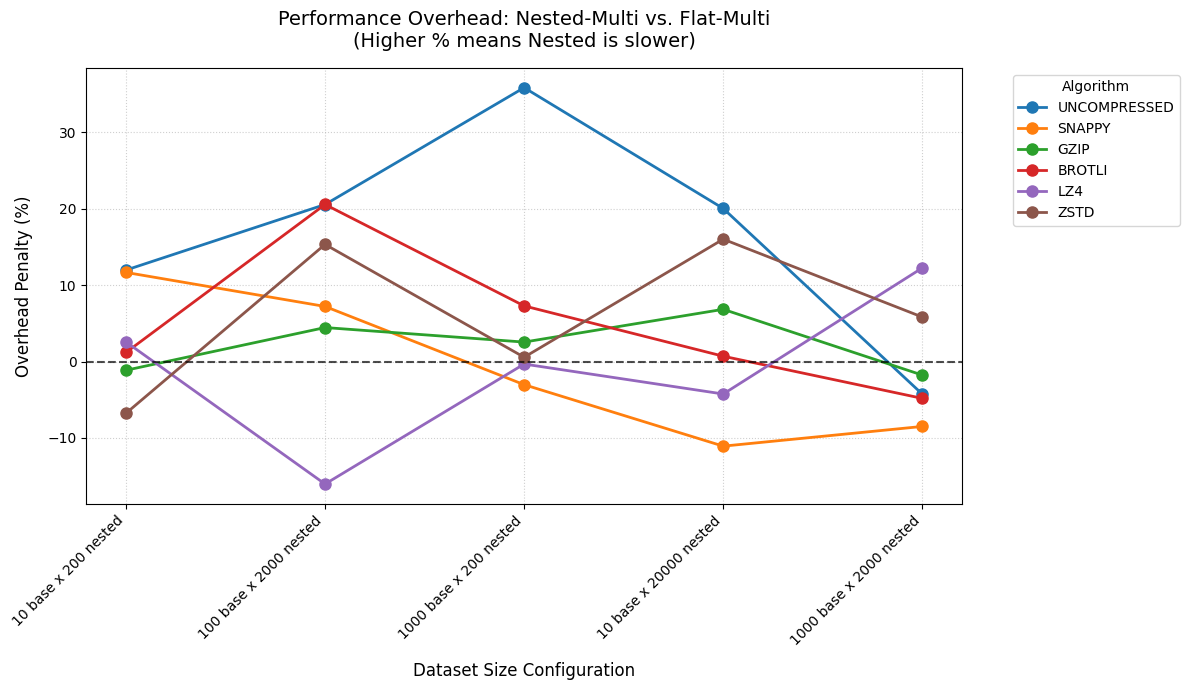

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Extract the list of sizes and compressions from our metrics dictionary
size_labels = list(all_metrics.keys())
compressions = list(all_metrics[size_labels[0]].keys())

# Plot one line for each compression algorithm
for comp_name in compressions:
    y_values = []
    
    for size in size_labels:
        times = all_metrics[size][comp_name]
        flat_m_time = times['flat_multi']
        nest_m_time = times['nested_multi']
        
        # Calculate Overhead Penalty (%)
        # Formula: ((Nested Time - Flat Time) / Flat Time) * 100
        # Positive value = Nested took MORE time (it has a penalty/overhead)
        # Negative value = Nested took LESS time (it is somehow faster)
        overhead_pct = ((nest_m_time - flat_m_time) / flat_m_time) * 100
        y_values.append(overhead_pct)
        
    plt.plot(
        size_labels, 
        y_values, 
        marker='o', 
        markersize=8, 
        linewidth=2, 
        label=comp_name.upper()
    )

# Formatting the chart
plt.title("Performance Overhead: Nested-Multi vs. Flat-Multi\n(Higher % means Nested is slower)", fontsize=14, pad=15)
plt.xlabel("Dataset Size Configuration", fontsize=12, labelpad=10)
plt.ylabel("Overhead Penalty (%)", fontsize=12, labelpad=10)

# Add a baseline at 0% (where Nested and Flat take the exact same amount of time)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# Rotate X-axis labels so they don't overlap if you have many sizes
plt.xticks(rotation=45, ha='right')

# Styling
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Algorithm", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Render the plot
plt.show()

In [3]:
import pyarrow as pa
pa.__version__
# > '22.0.0'

'25.0.0a1.dev18824+gfdade6460'

In [ ]:
# struct of lists storage as read by pyarrow
pa.parquet.read_table("nested_parquet.parquet").field("nested")
# > pyarrow.Field<nested: struct<t: list<element: double>, flux: list<element: double>, band: list<element: string>>>

In [ ]:
# list storage as read by pyarrow
pa.parquet.read_table("list_parquet.parquet").field("t")
# > pyarrow.Field<t: list<element: double>>

In [ ]:
import os
import gc
import time
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from nested_pandas.datasets import generate_data

# ==========================================
# 1. OS & Memory Helper Functions
# ==========================================
def format_size(size_in_bytes):
    for unit in ['B', 'KB', 'MB', 'GB']:
        if size_in_bytes < 1024.0:
            return f"{size_in_bytes:.2f} {unit}"
        size_in_bytes /= 1024.0

def pre_warm_cache(filepath):
    """Reads raw bytes to force the OS to load the file into RAM."""
    with open(filepath, 'rb') as f:
        while f.read(10 * 1024 * 1024):
            pass

# ==========================================
# 2. Benchmarking Functions
# ==========================================
def benchmark_warm_read(filepath, use_threads, num_runs=100):
    """Pre-warms cache once, then times pure CPU/RAM speed."""
    pre_warm_cache(filepath) # Force Warm
    total_time = 0.0
    for _ in range(num_runs):
        start_time = time.perf_counter()
        table = pa.parquet.read_table(filepath, use_threads=use_threads)
        total_time += (time.perf_counter() - start_time)
        del table
        gc.collect()
    return total_time / num_runs

# ==========================================
# 3. Configurations
# ==========================================
size_configs = [
    # ==========================================
    # 10^2 (100 items) - Micro Scale
    # ==========================================
    (10, 10),

    # ==========================================
    # 10^3 (1,000 items)
    # ==========================================
    (10, 100),        # Extremely Deep
    (100, 10),        # Extremely Wide

    # ==========================================
    # 10^4 (10,000 items)
    # ==========================================
    (10, 1000),       # Extremely Deep
    (100, 100),       # Balanced
    (1000, 10),       # Extremely Wide

    # ==========================================
    # 10^5 (100,000 items) 
    # ==========================================
    (10, 10000),      # Extremely Deep
    (100, 1000),      # Deep
    (1000, 100),      # Wide
    (10000, 10),      # Extremely Wide

    # ==========================================
    # 10^6 (1 Million items) ~ Approx 8 MB uncompressed
    # ==========================================
    (10, 100000),     # Extremely Deep
    (100, 10000),     # Deep
    (1000, 1000),     # Balanced
    (10000, 100),     # Wide
    (100000, 10),     # Extremely Wide

    # ==========================================
    # 10^7 (10 Million items) ~ Approx 80 MB uncompressed
    # ==========================================
    (10, 1000000),    # Extremely Deep
    (100, 100000),    # Deep
    (1000, 10000),    # Slightly Deep
    (10000, 1000),    # Slightly Wide
    (100000, 100),    # Wide
    (1000000, 10),    # Extremely Wide

    # ==========================================
    # 10^8 (100 Million items) ~ Approx 800 MB uncompressed
    # ==========================================
    (10, 10000000),   # Extremely Deep
    (100, 1000000),   # Deep
    (1000, 100000),   # Slightly Deep
    (10000, 10000),   # Balanced
    (100000, 1000),   # Slightly Wide
    (1000000, 100),   # Wide
    (10000000, 10),   # Extremely Wide

    # ==========================================
    # 10^9 (1 Billion items) ~ Approx 8 GB uncompressed
    # DANGER: Requires massive system RAM!
    # ==========================================
    # (10, 100000000),  # Extremely Deep
    # (100, 10000000),  # Deep
    # (1000, 1000000),  # Slightly Deep
    # (31622, 31622),   # Balanced (sqrt of 10^9)
    # (1000000, 1000),  # Slightly Wide
    # (10000000, 100),  # Wide
    # (100000000, 10),  # Extremely Wide
]
compressions = [None, 'snappy', 'gzip', 'brotli', 'lz4', 'zstd']
all_metrics = {}

# ==========================================
# 4. Main Execution Pipeline
# ==========================================
for base_rows, nested_rows in size_configs:
    size_label = f"{base_rows}x{nested_rows}"
    all_metrics[size_label] = {}
    
    print(f"\n{'='*60}\nGenerating & Testing: {size_label}\n{'='*60}")
    nf = generate_data(base_rows, nested_rows, seed=1)[["nested"]]
    nf_lists = nf["nested"].to_lists()
    
    for comp in compressions:
        comp_name = "uncompressed" if comp is None else comp
        nested_file, list_file = f"temp_n_{comp_name}.parquet", f"temp_l_{comp_name}.parquet"
        
        nf.to_parquet(nested_file, compression=comp)
        nf_lists.to_parquet(list_file, compression=comp)
        
        all_metrics[size_label][comp_name] = {}
            
        print(f"  [{comp_name.upper()}] Running Warm Benchmarks (CPU Only)...")
        for threading in [False, True]:
            t_label = "multi" if threading else "single"
            all_metrics[size_label][comp_name][f'warm_flat_{t_label}'] = benchmark_warm_read(list_file, threading)
            all_metrics[size_label][comp_name][f'warm_nest_{t_label}'] = benchmark_warm_read(nested_file, threading)

        os.remove(nested_file)
        os.remove(list_file)

    del nf, nf_lists
    gc.collect()

# ==========================================
# 5. Print Comparison Table
# ==========================================
print("\n" + "#"*60)
print(f"{'FINAL TIMES (Seconds) - WARM, MULTITHREADED ONLY':^60}")
print("#"*60)

for size, comps in all_metrics.items():
    print(f"\n=== Dataset Size: {size} ===")
    print(f"| {'Algorithm':<14} | {'WARM Flat':<12} | {'WARM Nest':<12} |")
    print("-" * 47)
    for comp_name, metrics in comps.items():
        w_f = metrics['warm_flat_multi']
        w_n = metrics['warm_nest_multi']
        print(f"| {comp_name.upper():<14} | {w_f:>10.4f} s | {w_n:>10.4f} s |")

# ==========================================
# 6. Plotting the Data
# ==========================================
size_labels = list(all_metrics.keys())
plt.figure(figsize=(12, 6))

for comp_name in [c if c is not None else "uncompressed" for c in compressions]:
    warm_y = []
    for size in size_labels:
        m = all_metrics[size][comp_name]
        # Calculate Overhead %: ((Nested - Flat) / Flat) * 100
        warm_y.append(((m['warm_nest_multi'] - m['warm_flat_multi']) / m['warm_flat_multi']) * 100)
        
    plt.plot(size_labels, warm_y, marker='o', linewidth=2, label=comp_name.upper())

plt.title("WARM Read Overhead (Pure CPU/RAM Performance)", fontsize=14, pad=15)
plt.ylabel("Nested Overhead Penalty (%)", fontsize=12)
plt.xlabel("Dataset Size Configuration (Base x Nested)", fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Algorithm", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==========================================
# 7. Automated Insights Extractor
# ==========================================
print("\n" + "#"*60)
print(f"{'AUTOMATED DATA INSIGHTS':^60}")
print("#"*60)

warm_avg_overhead = np.mean([((m['warm_nest_multi'] - m['warm_flat_multi']) / m['warm_flat_multi']) * 100 
                             for comps in all_metrics.values() for m in comps.values()])

print(f"1. Average CPU Penalty:")
print(f"   - Across all shapes and compressions, reading nested structures incurs an average CPU overhead of {warm_avg_overhead:.2f}%.")

worst_warm_overhead = 0
worst_warm_config = ""
for size, comps in all_metrics.items():
    for comp, m in comps.items():
        overhead = ((m['warm_nest_multi'] - m['warm_flat_multi']) / m['warm_flat_multi']) * 100
        if overhead > worst_warm_overhead:
            worst_warm_overhead = overhead
            worst_warm_config = f"{comp.upper()} at size {size}"

print(f"\n2. Worst-Case CPU Scenario:")
print(f"   - The highest CPU penalty for using Nested structures was {worst_warm_overhead:.2f}%.")
print(f"   - This occurred using {worst_warm_config}.")
print("   -> Conclusion: This specific data shape stresses PyArrow's C++ memory allocation engine the most during multithreaded decompression.")


Generating & Testing: 10x10
  [UNCOMPRESSED] Running Warm Benchmarks (CPU Only)...
  [SNAPPY] Running Warm Benchmarks (CPU Only)...
  [GZIP] Running Warm Benchmarks (CPU Only)...
  [BROTLI] Running Warm Benchmarks (CPU Only)...
  [LZ4] Running Warm Benchmarks (CPU Only)...
  [ZSTD] Running Warm Benchmarks (CPU Only)...

Generating & Testing: 10x100
  [UNCOMPRESSED] Running Warm Benchmarks (CPU Only)...
  [SNAPPY] Running Warm Benchmarks (CPU Only)...
  [GZIP] Running Warm Benchmarks (CPU Only)...
  [BROTLI] Running Warm Benchmarks (CPU Only)...
  [LZ4] Running Warm Benchmarks (CPU Only)...
  [ZSTD] Running Warm Benchmarks (CPU Only)...

Generating & Testing: 100x10
  [UNCOMPRESSED] Running Warm Benchmarks (CPU Only)...
  [SNAPPY] Running Warm Benchmarks (CPU Only)...
  [GZIP] Running Warm Benchmarks (CPU Only)...
  [BROTLI] Running Warm Benchmarks (CPU Only)...
  [LZ4] Running Warm Benchmarks (CPU Only)...
  [ZSTD] Running Warm Benchmarks (CPU Only)...

Generating & Testing: 10x1000
 

In [ ]:
import sqlite3
import pandas as pd

# 1. Connect to the local SQLite database (this creates the file if it doesn't exist)
db_name = "benchmark_results.db"
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

# 2. Define and create the table schema
# We use REAL for the timing metrics (floats in Python)
create_table_query = """
CREATE TABLE IF NOT EXISTS warm_benchmarks (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    run_timestamp DATETIME DEFAULT CURRENT_TIMESTAMP,
    base_rows INTEGER,
    nested_rows INTEGER,
    total_items INTEGER,
    compression TEXT,
    warm_flat_single REAL,
    warm_nest_single REAL,
    warm_flat_multi REAL,
    warm_nest_multi REAL,
    multi_overhead_pct REAL
);
"""
cursor.execute(create_table_query)

# 3. Parse the all_metrics dictionary and insert the data
insert_query = """
INSERT INTO warm_benchmarks (
    base_rows, nested_rows, total_items, compression, 
    warm_flat_single, warm_nest_single, warm_flat_multi, warm_nest_multi, multi_overhead_pct
) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
"""

# Count how many rows we insert to verify at the end
inserted_count = 0

print("Saving results to SQLite database...")

for size_label, comps in all_metrics.items():
    # Extract base and nested rows from the "100x1000" string format
    base_rows, nested_rows = map(int, size_label.split('x'))
    total_items = base_rows * nested_rows
    
    for comp_name, metrics in comps.items():
        w_f_s = metrics['warm_flat_single']
        w_n_s = metrics['warm_nest_single']
        w_f_m = metrics['warm_flat_multi']
        w_n_m = metrics['warm_nest_multi']
        
        # Calculate the multithreaded overhead percentage
        overhead_pct = ((w_n_m - w_f_m) / w_f_m) * 100
        
        # Execute the insert
        cursor.execute(insert_query, (
            base_rows, nested_rows, total_items, comp_name,
            w_f_s, w_n_s, w_f_m, w_n_m, overhead_pct
        ))
        inserted_count += 1

# 4. Commit the transaction to disk
conn.commit()
print(f"Success! {inserted_count} rows inserted into '{db_name}'.")

# ==========================================
# Optional: Verify the save by loading it back into a Pandas DataFrame
# ==========================================
print("\nVerifying database contents:")
df_saved = pd.read_sql_query("SELECT * FROM warm_benchmarks ORDER BY id DESC LIMIT 5", conn)
display(df_saved)

# Always close the connection when done
conn.close()